<a href="https://colab.research.google.com/github/parask29/Jamboree-Linear-Regression/blob/main/Jamboore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('Jamboree_Admission.csv')

In [5]:
# Problem statement :  Predict the chances of getting the admission

Basic EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [7]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [8]:
df['CGPA'].value_counts()

,count
CGPA,
8.00,9
8.76,9
8.56,7
8.12,7
8.45,7
...,...
7.57,1
7.21,1
9.27,1


In [9]:
df.shape

(500, 9)

In [10]:
# Check duplicates-- NO duplicay

df.duplicated().value_counts()

,count
False,500


In [11]:
# Missing value treatment --NO null value
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


<Axes: >

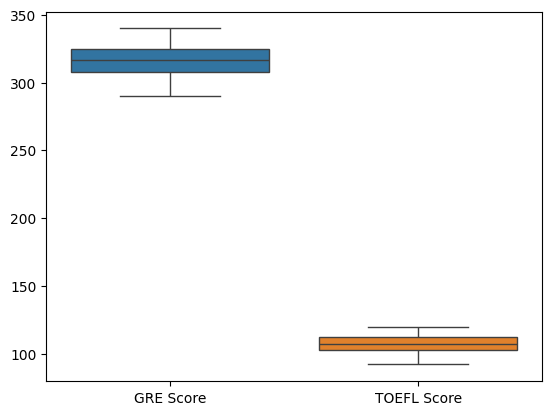

In [12]:
# Check outliers : No outliers

sns.boxplot(data = df[['GRE Score', 'TOEFL Score']])

In [13]:
# Remove outliers :
Q1 = df['GRE Score'].quantile(0.25)
Q3 = df['GRE Score'].quantile(0.75)
IQR = Q3-Q1

Lower_wisker = df[(df['GRE Score']>Q1 - 1.5*IQR)]
Upper_wisker = df[(df['GRE Score'] < Q3-1.5*IQR)]

Outliers = Upper_wisker - Lower_wisker
Outliers.sum()

,0
Serial No.,0.0
GRE Score,0.0
TOEFL Score,0.0
University Rating,0.0
SOP,0.0
LOR,0.0
CGPA,0.0
Research,0.0
Chance of Admit,0.0


In [14]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

<Axes: xlabel='Chance of Admit ', ylabel='Count'>

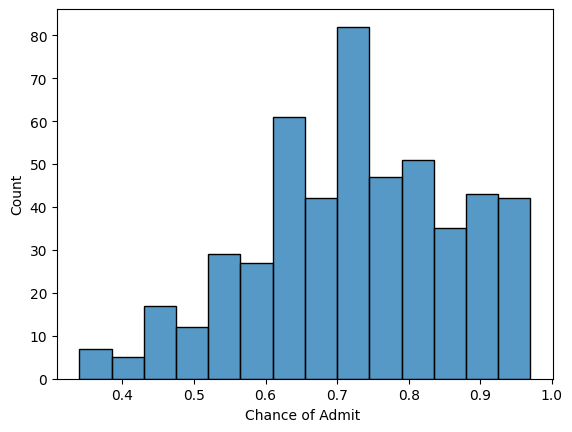

In [15]:
# Plot histogram plots

sns.histplot(df['Chance of Admit '])

<Axes: xlabel='GRE Score', ylabel='Count'>

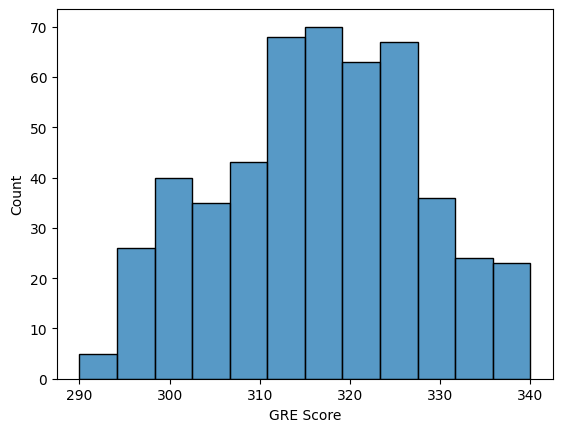

In [16]:
sns.histplot(df['GRE Score'])

<Axes: xlabel='TOEFL Score', ylabel='Count'>

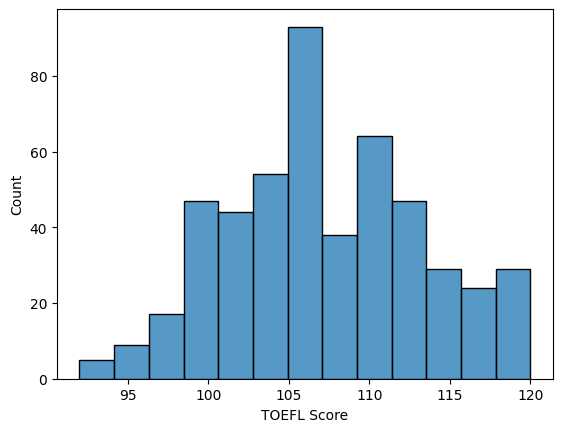

In [17]:
sns.histplot(df['TOEFL Score'])

<Axes: >

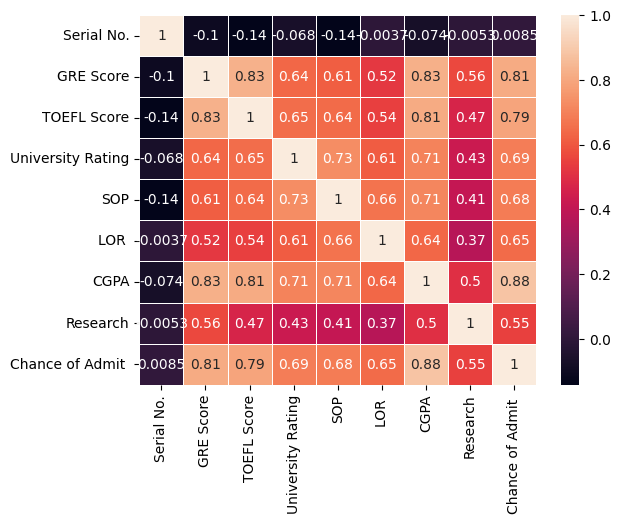

In [18]:
# Correlation

corr = df.corr()
sns.heatmap(data=corr, linewidth = 0.5, annot = True)

<Axes: >

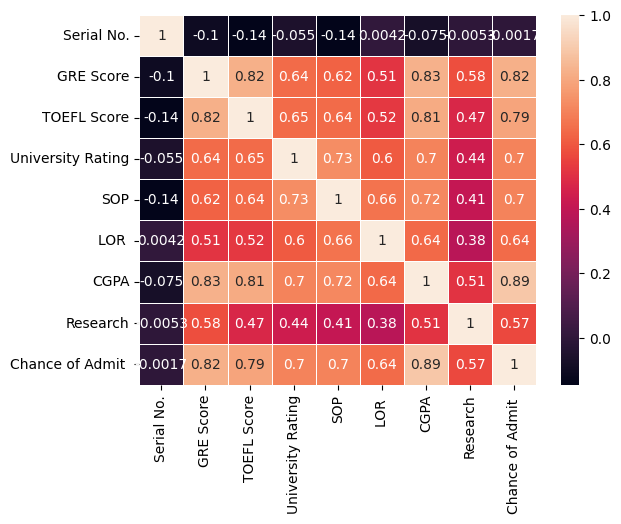

In [19]:
# Spearman Correlation

corr = df.corr(method = 'spearman',)
sns.heatmap(data=corr, linewidth = 0.5, annot = True)

# GRE Score, TOEFL score and CGPA are most correlated features

<Axes: xlabel='GRE Score', ylabel='TOEFL Score'>

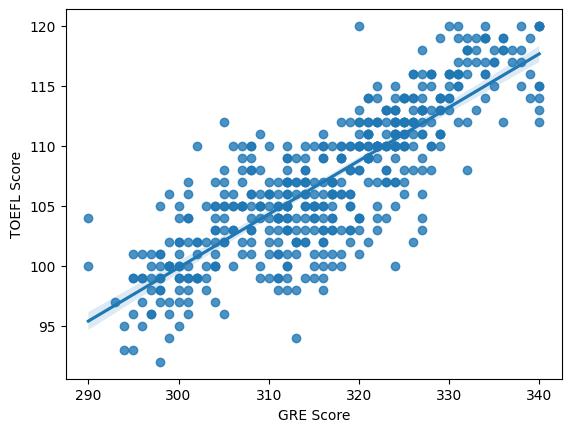

In [20]:
# Relation between Tofel score and gre score

sns.regplot(df, x = 'GRE Score', y = 'TOEFL Score')

Data preparation for modeling

In [94]:
# Leakage : what is leakage in machine learningData leakage in machine learning occurs when a model is trained using information that would not actually be available at the time of prediction in the real world. This causes the model to "cheat" during training and validation, resulting in deceptively high performance metrics that collapse entirely once the model is deployed to production.
# It is widely considered one of the most common and damaging mistakes in data science workflows
# Step 1 : Split--> X_train, X_test
# Step 2 : Then use StandardScaler, target encoding
# Otherwise Leakage will take place

from sklearn.model_selection import train_test_split

X = df.drop(['Chance of Admit '], axis= 1) # Features
y = df['Chance of Admit ']                 # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True)

In [96]:
X_train.shape

(400, 8)

In [95]:
# StandardScaler = Anywhere for standardization
# MinMaxScaler = When Upper and Lower limit is known. Outliers are not present

from sklearn.preprocessing import StandardScaler
X_train_columns = X_train.columns
std = StandardScaler()   # Value betweem (0,1)

X_train_std = std.fit_transform(X_train)

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

In [25]:
models = [
    ['Linear Regression :', LinearRegression()],
    ['Lasso Regression :', Lasso(alpha=0.01)],
    ['Ridge Regression :', Ridge(alpha = 0.1)]
]

In [26]:
for name, model in models:
  model.fit(X_train, y_train.values)
  y_pred = model.predict(std.transform(X_test))
  print(name, (np.sqrt(mean_squared_error(y_test, y_pred))))

## Linear reg is having best accuracy among other model
## Not removed any multicollinear column

Linear Regression : 0.06830519710149931
Lasso Regression : 0.07212197900622265
Ridge Regression : 0.0683073529530283


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [27]:
## Considering multicollinrearty


import statsmodels.api as sm

X_train = sm.add_constant(X_train)
model = sm.OLS(y_train.values, X_train).fit()

print(model.summary())

# Remove Univer rating and SOP having High Pvalue so remove for increasing accuracy

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     252.0
Date:                Mon, 01 Jun 2026   Prob (F-statistic):          3.78e-149
Time:                        14:16:36   Log-Likelihood:                 586.66
No. Observations:                 400   AIC:                            -1155.
Df Residuals:                     391   BIC:                            -1119.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7258      0.00

In [28]:
## Calculating VIF : For feature importance

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train_new = X_train.columns

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

print(vif_data)

# seems all features are important as VIF<5

             Feature       VIF
0              const  1.000000
1         Serial No.  1.075843
2          GRE Score  4.587804
3        TOEFL Score  3.912713
4  University Rating  2.538615
5                SOP  3.093735
6               LOR   2.106224
7               CGPA  5.105394
8           Research  1.587035


Testing the assumptions of the linear regression model :

In [29]:
# Mean of Residuals:

residual = y_test.values - y_pred
residual.mean()

## close to Zero

np.float64(-0.015429326605573163)

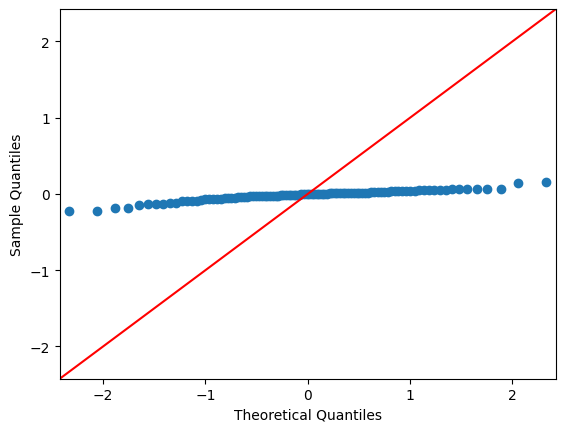

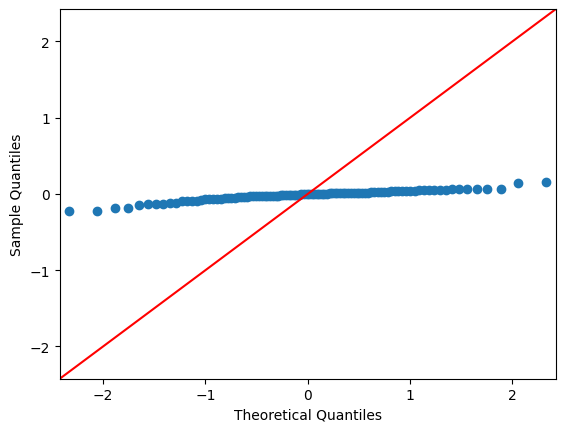

In [30]:
## Check normality of Residuals

sm.qqplot(residual, line = '45')


<Axes: >

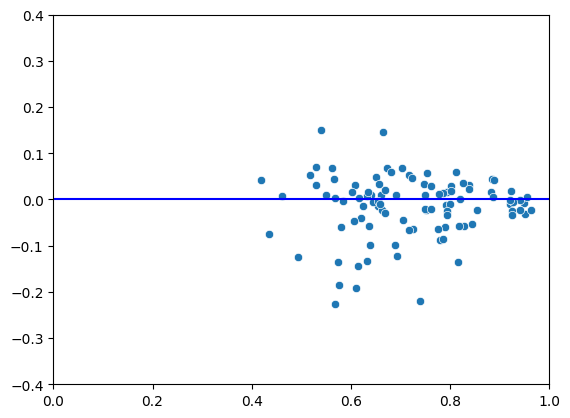

In [31]:
## Check Homoskedasticity check - Variance of residuals is constant

sns.scatterplot(x = y_pred, y = residual)

plt.xlim(0,1)
plt.ylim(-0.4, 0.4)

sns.lineplot(x = [0,26], y = [0,0], color = 'Blue')

# More residual variance before 0.8

# Check value of homosked ===  DIY




<Axes: ylabel='Count'>

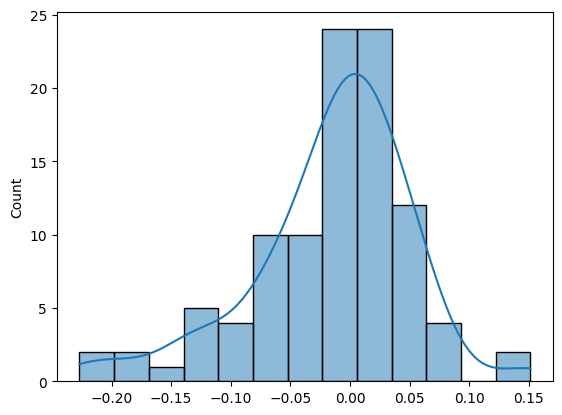

In [34]:
sns.histplot(residual, kde = True)

Model performance evaluation

In [ ]:
from sklearn.metrics import mean_squared_error

X_train_std, X_test, y_train, y_test


In [101]:
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
y_train_value = y_train.values

In [102]:
model = LinearRegression()
model.fit(X_train_std, y_train_value)

LinearRegression()

In [ ]:
model.predict(X_test)

In [104]:
from sklearn.metrics import mean_squared_error

In [105]:
mean_squared_error(y_test, y_pred)

0.03241113583045939

In [108]:
mean_squared_error(y_test, y_pred)

0.03241113583045939

In [110]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

-0.6460616944475877